In [1]:
import easysnowdata
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
import shapely
import dask
import pystac_client
import planetary_computer
import odc.stac
import matplotlib.pyplot as plt
import matplotlib.colors
import datetime
import pandas as pd
import numpy as np
import contextily as ctx
import rasterio as rio

import datetime

today = datetime.datetime.now().strftime("%Y-%m-%d")

In [2]:
bbox_snow = (-123.88,47.5,-123,48.04)  # Centering on snow in the park

Data searched. Access the returned seach with the .search attribute.
Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.
Nodata values removed from the data. In doing so, all bands converted to float32. To turn this behavior off, set remove_nodata=False.
Data acquired after January 25th, 2022 harmonized to old baseline. To override this behavior, set harmonize_to_old=False.
Data scaled to float reflectance. To turn this behavior off, set scale_data=False.
Metadata retrieved. Access with the .metadata attribute.
NDSI data calculated. Access with the .ndsi attribute.


/opt/conda/lib/python3.11/site-packages/dask/_task_spec.py:740: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


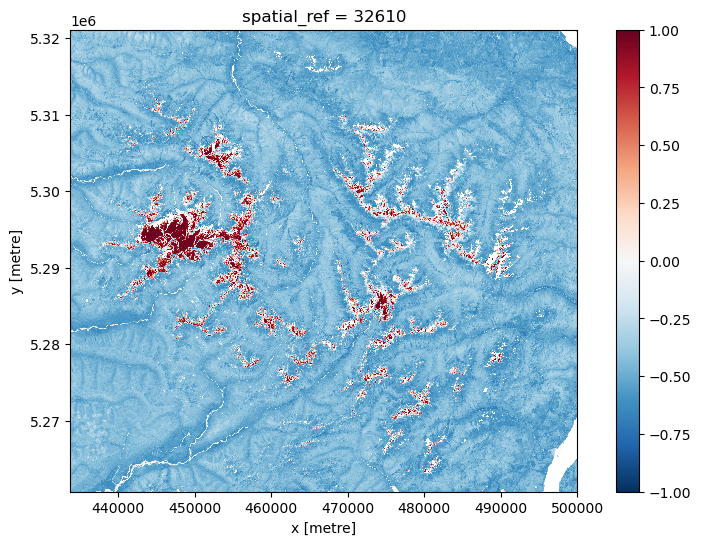

In [3]:
s2_2022_wy = easysnowdata.remote_sensing.Sentinel2(
    bbox_input=bbox_snow,
    start_date="2022-07-15",
    end_date="2022-08-15",
    catalog_choice="planetarycomputer",
    resolution=30,
)

s2_2022_wy.get_ndsi()

bad_scl = [0,1,2,3,6,8,9,10]

f, ax =plt.subplots(figsize =(10,6))
ndsi_median_composite_2022 = s2_2022_wy.ndsi.where(~s2_2022_wy.data.scl.isin(bad_scl)).median(dim='time').compute()  # Now grabbing just our desired dates 
ndsi_median_composite_2022.plot.imshow(cmap ='RdBu_r', robust=True, vmin=-1, vmax=1)
ax.set_aspect('equal')

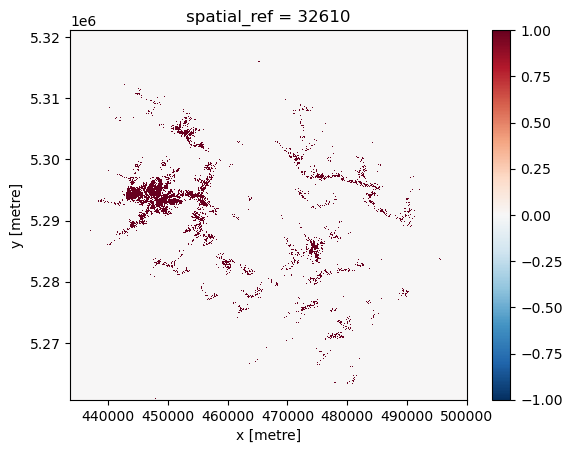

In [4]:
# s2_2022_wy = easysnowdata.remote_sensing.Sentinel2(
#     bbox_input=bbox_snow,
#     start_date="2022-07-15",
#     end_date="2022-08-15",
#     catalog_choice="planetarycomputer",
#     resolution=30,
# )

# s2_2022_wy.get_ndsi()

# bad_scl = [0,1,2,3,6,8,9,10]

# ndsi_median_composite_2022 = s2_2022_wy.ndsi.where(~s2_2022_wy.data.scl.isin(bad_scl)).median(dim='time').compute()  

snow_mask_2022 = (ndsi_median_composite_2022 > 0.4).astype(int)
snow_mask_2022.plot.imshow(cmap='RdBu_r', robust=True, vmin=-1, vmax=1)

In [5]:
snow_mask_pixels_2022 = int(snow_mask_2022.sum())
res = 30

In [6]:
snow_mask_extent_2022 = snow_mask_pixels_2022*((res*res)/1E6)
print(f"Snow extent in July-Aug 2022: {snow_mask_pixels_2022*((res*res)/1E6):.2f}km^2")

Snow extent in July-Aug 2022: 97.87km^2


Data searched. Access the returned seach with the .search attribute.
Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.
Nodata values removed from the data. In doing so, all bands converted to float32. To turn this behavior off, set remove_nodata=False.
Data acquired after January 25th, 2022 harmonized to old baseline. To override this behavior, set harmonize_to_old=False.
Data scaled to float reflectance. To turn this behavior off, set scale_data=False.
Metadata retrieved. Access with the .metadata attribute.
NDSI data calculated. Access with the .ndsi attribute.


/opt/conda/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


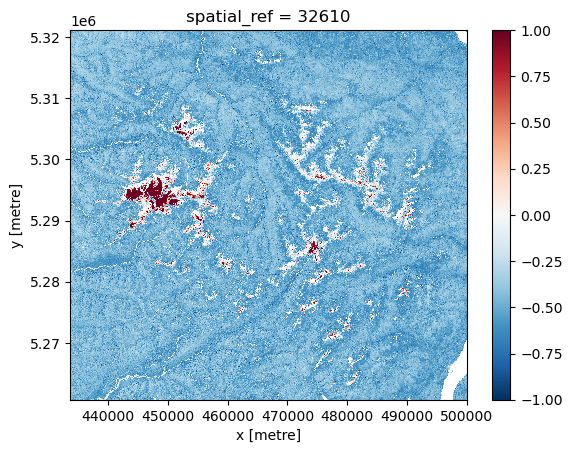

In [7]:
s2_2023_wy = easysnowdata.remote_sensing.Sentinel2(
    bbox_input=bbox_snow,
    start_date="2023-07-15",
    end_date="2023-08-15",
    catalog_choice="planetarycomputer",
    resolution=30,
)

s2_2023_wy.get_ndsi()

bad_scl = [0,1,2,3,6,8,9,10]

ndsi_median_composite_2023 = s2_2023_wy.ndsi.where(~s2_2023_wy.data.scl.isin(bad_scl)).median(dim='time').compute()  # Now grabbing just our desired dates 
ndsi_median_composite_2023.plot.imshow(cmap='RdBu_r', robust=True, vmin=-1, vmax=1)

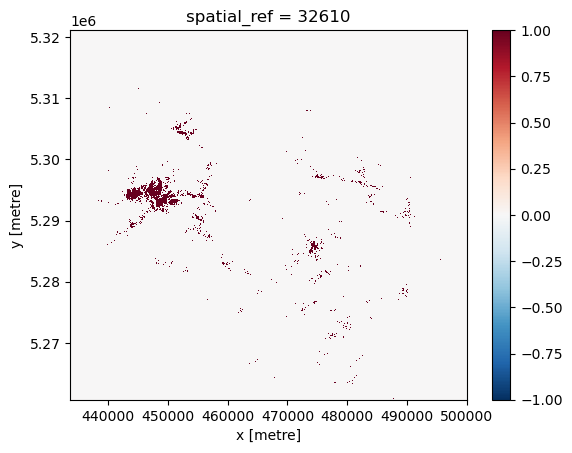

In [8]:
# s2_2023_wy = easysnowdata.remote_sensing.Sentinel2(
#     bbox_input=bbox_snow,
#     start_date="2023-07-15",
#     end_date="2023-08-15",
#     catalog_choice="planetarycomputer",
#     resolution=30,
# )

# s2_2023_wy.get_ndsi()

# bad_scl = [0,1,2,3,6,8,9,10]

# ndsi_median_composite_2023 = s2_2023_wy.ndsi.where(~s2_2023_wy.data.scl.isin(bad_scl)).median(dim='time').compute()  

snow_mask_2023 = (ndsi_median_composite_2023 > 0.4).astype(int)
snow_mask_2023.plot.imshow(cmap='RdBu_r', robust=True, vmin=-1, vmax=1)

In [9]:
snow_mask_pixels_2023 = int(snow_mask_2023.sum())
res = 30

In [10]:
snow_mask_extent_2023 = snow_mask_pixels_2023*((res*res)/1E6)
print(f"Snow extent in July-Aug 2023: {snow_mask_pixels_2023*((res*res)/1E6):.2f}km^2")

Snow extent in July-Aug 2023: 40.92km^2


In [11]:
#Calculating snow extent differences between years:
snow_diff_22_23 = snow_mask_2023 - snow_mask_2022
# Snow masks are from 0-1, (true=snow=1 or not), so anywhere either have nonzero values in their individual maskes, the plots should plot without 0 values in mask using:
snow_diff_22_23 = snow_diff_22_23.where((snow_mask_2023+snow_mask_2022) > 0)

Removed pixels with the following scene classification values:
No Data (Missing data)
Saturated or defective pixel
Topographic casted shadows
Cloud shadows
Cloud medium probability
Cloud high probability
Thin cirrus
RGB data retrieved.
Access with the following attributes:
.rgb for raw RGB,
.rgba for RGBA,
.rgb_percentile for percentile RGB,
.rgb_clahe for CLAHE RGB.
You can pass in percentile_kwargs and clahe_kwargs to adjust RGB calculations, check documentation for options.


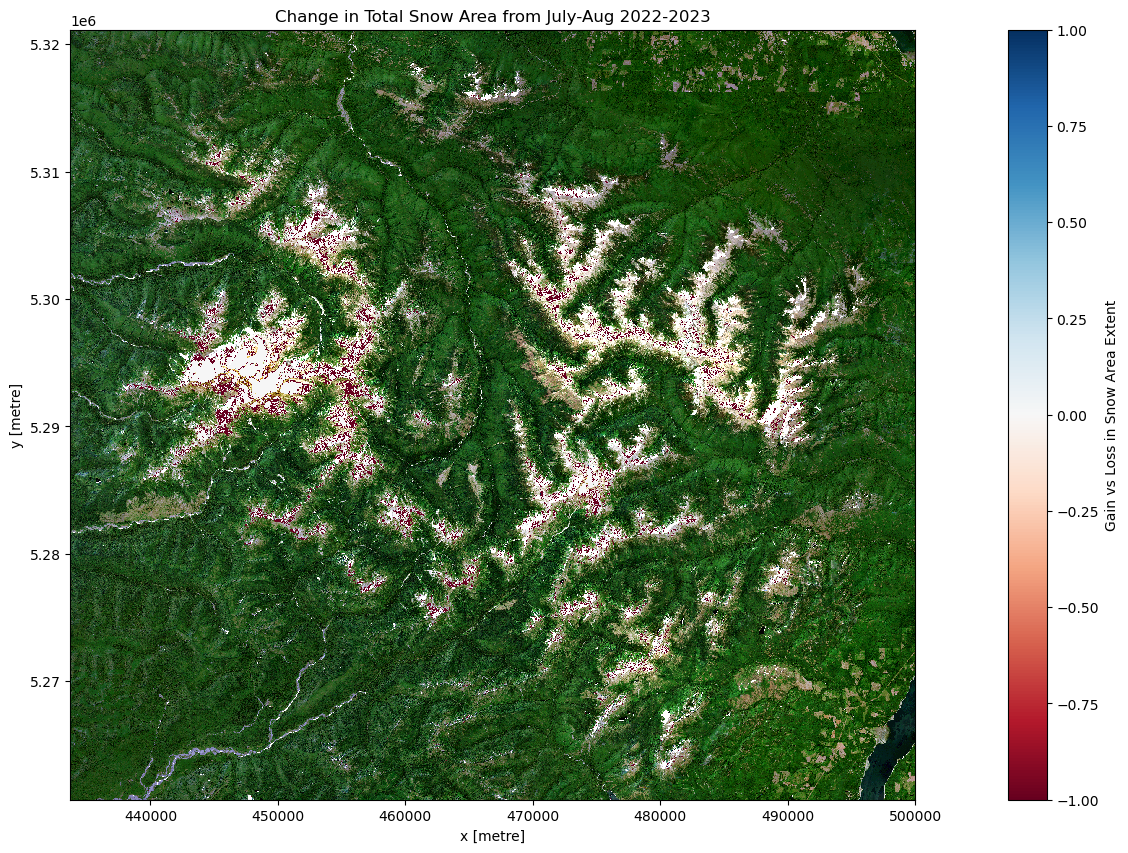

In [18]:
# s2_2023_wy = easysnowdata.remote_sensing.Sentinel2(
#     bbox_input=bbox,
#     start_date="2023-07-15",
#     end_date="2023-08-15",
#     catalog_choice="planetarycomputer",
#     resolution=30,
# )

#Defaults to: No Data, Saturated pixels, topographic shadows, cloud shadows, cloud medium probability, cloud high probability and thin cirrus, , which are all then removed
s2_2023_wy.mask_data()

s2_2023_wy.get_rgb()

rgb_median_composite_2023 = s2_2023_wy.rgb_clahe.median(dim='time').compute()  


f, ax = plt.subplots(figsize=(24,10))
rgb_median_composite_2023.plot.imshow(ax=ax, robust=True)
snow_diff_22_23.plot.imshow(ax=ax, cmap='RdBu', robust=True, vmin=-1, vmax=1, alpha=1, cbar_kwargs={'label':'Gain vs Loss in Snow Area Extent'})
ax.set_title('Change in Total Snow Area from July-Aug 2022-2023')
ax.set_aspect('equal')

In [19]:
#Reading in glacier shapefile
west_NA_glaciers = gpd.read_file('data/Western_NA_RGI_data/RGI2000-v7.0-C-02_western_canada_usa.shp')
#Checking data crs
print(west_NA_glaciers.crs)

EPSG:4326


In [20]:
west_NA_glaciers_gpd = west_NA_glaciers.to_crs(rgb_median_composite_2023.rio.crs)
west_NA_glaciers_gpd.total_bounds

array([ -13438.14373184, 4037073.10772943, 1988758.31206249,
       7268643.35502717])

In [21]:
xmin, ymin, xmax, ymax = rgb_median_composite_2023.rio.bounds()
ONP_glaciers_gdf = west_NA_glaciers_gpd.cx[xmin:xmax, ymin:ymax]

In [23]:
#Filtering snow mask to only values with snow, the rest become nans (so they don't plot)
snow_mask_2022_filter = snow_mask_2022 == 1
snow_mask_shape_2022 = snow_mask_2022.where(snow_mask_2022_filter)

snow_mask_2023_filter = snow_mask_2023 == 1
snow_mask_shape_2023 = snow_mask_2023.where(snow_mask_2023_filter)

In [24]:
glaciers_2022 = snow_mask_shape_2022.rio.clip(ONP_glaciers_gdf.geometry)
glaciers_2023 = snow_mask_shape_2023.rio.clip(ONP_glaciers_gdf.geometry)

In [25]:
res = 30
glacier_2022_pixels = int(glaciers_2022.sum())
glacier_2023_pixels = int(glaciers_2023.sum())

In [26]:
glacier_extent_2022 = glacier_2022_pixels*((res*res)/1E6)
print(f"Glacier only snow extent in July-Aug 2022: {glacier_2022_pixels*((res*res)/1E6):.2f}km^2")

glacier_extent_2023 = glacier_2023_pixels*((res*res)/1E6)
print(f"Glacier only snow extent in July-Aug 2023: {glacier_2023_pixels*((res*res)/1E6):.2f}km^2")

Glacier only snow extent in July-Aug 2022: 33.94km^2
Glacier only snow extent in July-Aug 2023: 27.32km^2


In [27]:
glaciers_2022_mask = glaciers_2022 > 0 
glaciers_2023_mask = glaciers_2023 > 0 

In [28]:
snow_no_glacier_2022 = snow_mask_shape_2022.where(~glaciers_2022_mask)
snow_no_glacier_2023 = snow_mask_shape_2023.where(~glaciers_2023_mask)

In [29]:
snow_no_glacier_2022_pixels = int(snow_no_glacier_2022.sum())
snow_no_glacier_2023_pixels = int(snow_no_glacier_2023.sum())

In [30]:
snow_only_extent_2022 = snow_no_glacier_2022_pixels*((res*res)/1E6)
print(f"Glacier excluded snow extent in July-Aug 2022: {snow_no_glacier_2022_pixels*((res*res)/1E6):.2f}km^2")

snow_only_extent_2023 = snow_no_glacier_2023_pixels*((res*res)/1E6)
print(f"Glacier excluded snow extent in July-Aug 2023: {snow_no_glacier_2023_pixels*((res*res)/1E6):.2f}km^2")

Glacier excluded snow extent in July-Aug 2022: 61.02km^2
Glacier excluded snow extent in July-Aug 2023: 13.24km^2


In [31]:
extent_diff_2022 = snow_mask_extent_2022 - (glacier_extent_2022 + snow_only_extent_2022)
print(f"Difference in snow extent area components from whole mask for 2022: {extent_diff_2022:.2f}km^2")

extent_diff_2023 = snow_mask_extent_2023 - glacier_extent_2023 - snow_only_extent_2023
print(f"Difference in snow extent area components from whole mask for 2023: {extent_diff_2023:.2f}km^2")

Difference in snow extent area components from whole mask for 2022: 2.91km^2
Difference in snow extent area components from whole mask for 2023: 0.36km^2


In [32]:
#Having issues with nan values, so have to set all to integer 0 for difference to work
snow_only_2022_int = snow_no_glacier_2022.fillna(0).astype(int)
snow_only_2023_int = snow_no_glacier_2023.fillna(0).astype(int)

#Calculating snow extent differences between years but now excluding glaciers:
snow_only_diff_22_23 = snow_only_2023_int  - snow_only_2022_int
snow_only_diff_22_23 = snow_only_diff_22_23.where((snow_only_2023_int+snow_only_2022_int) > 0)

In [ ]:
# s2_2023_wy = easysnowdata.remote_sensing.Sentinel2(
#     bbox_input=bbox_snow,
#     start_date="2023-07-15",
#     end_date="2023-08-15",
#     catalog_choice="planetarycomputer",
#     resolution=30,
# )

# #Defaults to: No Data, Saturated pixels, topographic shadows, cloud shadows, cloud medium probability, cloud high probability and thin cirrus, , which are all then removed
# s2_2023_wy.mask_data()

# s2_2023_wy.get_rgb()

# rgb_median_composite_2023 = s2_2023_wy.rgb_clahe.median(dim='time').compute()  


# f, ax = plt.subplots(figsize=(24,10))
# rgb_median_composite_2023.plot.imshow(ax=ax, robust=True)
# snow_only_diff_22_23.plot.imshow(ax=ax, cmap='RdBu', robust=True, vmin=-1, vmax=1, alpha=1)
# ax.add_title('Change in snow area outside of glaciers')
# ax.set_aspect('equal')

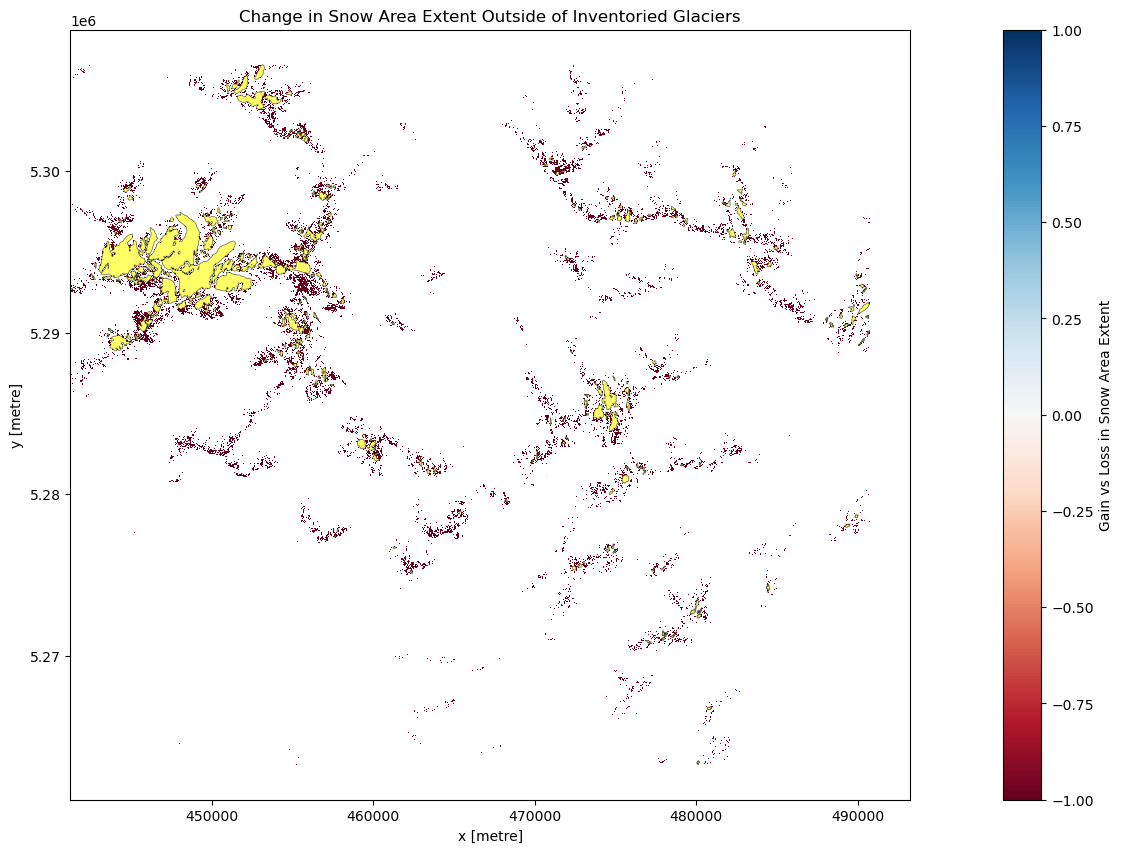

In [34]:
f, ax = plt.subplots(figsize=(24,10))
snow_only_diff_22_23.plot.imshow(ax=ax, cmap='RdBu', robust=True, vmin=-1, vmax=1, alpha=1, cbar_kwargs={'label':'Gain vs Loss in Snow Area Extent'})
ONP_glaciers_gdf.plot(ax=ax, color= 'yellow', edgecolor='k', alpha=0.6, lw=0.5)
ax.set_title('Change in Snow Area Extent Outside of Inventoried Glaciers')
ax.set_aspect('equal')